## An AI to Help Reduce Heating Bills

In [ ]:
import math
import pymc3 as pm
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

We have external temperature data (in degree C) for each day of the year.

In [ ]:
external_temp = np.array([-4.3, -6.1, -8.5, -0.5,  2.3,  3.1,  3.3,  7.8,  8.5,  9.7, -0.6,
                          -2.0,  4.2,  8.4,  8.9,  9.0,  4.4,  0.5,  0.7,  2.2,  3.7,  1.8,
                           4.2,  3.8,  4.6,  0.6, -0.2,  8.7,  6.7, -1.7, 10.9, -6.7,  1.3,
                           5.1,  5.3,  9.7, 12.0,  5.2, 10.6,  9.5,  4.3,  0.3, -0.2, -1.2,
                          -1.6, -5.0, -5.6, -4.0, -5.2, -4.5, -6.0, -1.2,  2.6, -0.9, -3.8,
                          -5.5,  3.3, 12.8, 11.9, -2.7, -0.2, -0.9, -1.6,  5.0,  5.7,  5.6,
                           4.2, -0.1,  6.1,  8.8,  7.4, 12.7, 11.0, 14.7, 11.5, 14.6,  9.7,
                           5.7,  8.2, 10.6,  9.4,  5.1,  4.7,  2.9, -0.4,  2.1,  5.3,  8.5,
                          11.9,  5.3, 11.8, 11.3,  6.6,  7.1,  8.1,  6.3,  9.0, 11.2, 11.8,
                          14.6, 15.2, 17.7, 10.7,  7.5,  9.5,  4.9,  1.6,  2.9,  0.9, -0.2,
                           4.3,  6.5,  7.7, 10.4,  7.6,  7.6,  7.3,  8.0,  6.7,  6.6, 14.2,
                          10.3,  8.9,  8.3, 11.6, 11.4,  9.6, 11.2, 13.6, 16.9, 19.6, 17.6,
                          11.8, 12.4,  9.9, 12.1, 21.1, 14.8, 14.9, 10.0, 13.5, 16.3, 21.5,
                          24.2, 16.4, 12.5, 12.4, 14.1, 17.5, 16.9, 18.2, 18.5, 17.1, 17.9,
                          20.3, 18.1, 16.1, 24.8, 26.6, 22.9, 19.9, 18.5, 19.6, 15.9, 17.3,
                          14.7, 14.6, 20.8, 19.5, 21.5, 23.7, 22.0, 25.1, 21.3, 16.3, 22.4,
                          22.6, 16.2, 20.7, 23.6, 18.4, 22.4, 23.8, 24.5, 27.6, 28.7, 27.8,
                          27.6, 23.3, 24.7, 26.9, 27.7, 22.3, 24.4, 25.7, 23.9, 22.9, 22.8,
                          23.0, 23.1, 23.6, 23.6, 25.3, 24.7, 20.6, 23.2, 26.1, 27.2, 27.2,
                          31.1, 25.2, 25.8, 23.4, 22.8, 19.4, 24.2, 29.2, 23.1, 21.1, 21.9,
                          25.6, 22.7, 22.1, 24.7, 24.8, 22.8, 24.7, 26.6, 28.3, 33.6, 35.0,
                          28.5, 27.2, 22.2, 20.9, 20.8, 20.8, 18.5, 19.0, 18.9, 18.9, 17.6,
                          18.6, 23.5, 20.6, 18.0, 18.4, 17.5, 20.6, 22.7, 21.9, 22.1, 17.3,
                          20.0, 15.8, 16.6, 16.2, 17.2, 17.5, 18.9, 22.8, 20.6, 16.4, 19.4,
                          20.8, 17.8, 15.0, 15.8, 19.0, 13.8, 10.0, 11.5, 12.4, 11.2, 11.1,
                           9.7, 12.7, 15.4, 15.1, 12.0, 12.9, 12.5,  7.3,  9.0, 12.2, 10.9,
                           9.2, 14.8, 16.2, 15.4, 18.8, 21.1, 15.1, 11.6, 16.6, 14.4, 14.4,
                          18.4, 20.2, 17.8,  9.9, -0.4, -2.8, -1.9,  9.9,  5.7,  4.7,  5.6,
                           4.2,  4.3,  7.2,  5.1,  5.4, 13.4, 13.8, 17.3, 16.6, 13.9, 13.7,
                          18.6, 14.1,  9.5,  6.4,  1.6,  1.2, -4.2, -0.7,  2.0,  1.9,  5.5,
                           3.1,  4.7,  2.2,  5.1,  9.1,  5.5,  7.7,  9.6, 12.7,  6.5,  7.4,
                           1.8,  3.8,  4.9, -2.5, -0.9,  0.9,  3.5, -3.5,  0.2,  1.4, -0.7,
                           8.6,  9.5,  3.1,  7.0, 14.5,  5.3,  0.9, -3.8, -3.0, -4.1, -1.7,
                           5.9,  5.8]);

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(external_temp);
plt.xlim(0, 364)
plt.xlabel('Day of year')
plt.ylabel('External Temperature (C)');

In [ ]:
def plotEnergyAgainstTime(title, data):
    plt.figure(figsize=(10, 4))
    plt.plot(data, '+');
    plt.xlim(0, 364)
    plt.title(title)
    plt.xlabel('Day of year')
    plt.ylabel('Daily Energy Consumption (kWh)');
    
def plotEnergyAgainstTemperature(title, temp, data):
    plt.figure(figsize=(6, 6))
    plt.plot(temp, data, '+')
    plt.xlim(-10, 30)
    plt.title(title)
    plt.ylabel("Daily Electricity Consumption (kWh)")
    plt.xlabel("External Temperature (C)");

We have the daily energy consumption (kWh) each day of the year for five houses.

In [ ]:
energy_house_1 = np.array([45.9, 53.5, 54.3, 43.9, 41.3, 39.2, 42.7, 35.7, 32.7, 41.3, 45.8,
                           45.5, 36.7, 35.0, 32.2, 36.0, 39.3, 47.6, 47.2, 50.0, 43.7, 36.9,
                           45.1, 38.0, 38.3, 42.5, 43.8, 31.3, 35.4, 48.6, 37.7, 56.0, 42.9,
                           39.3, 43.6, 32.6, 32.4, 36.9, 30.8, 35.9, 43.2, 40.4, 49.1, 49.1,
                           46.6, 62.8, 52.3, 51.8, 47.4, 52.6, 55.5, 47.0, 39.6, 42.0, 50.6,
                           54.1, 41.3, 26.4, 30.2, 48.5, 41.3, 48.9, 51.8, 42.5, 31.4, 46.8,
                           42.0, 48.4, 42.9, 29.0, 38.7, 28.8, 26.0, 27.7, 26.1, 28.9, 31.3,
                           38.8, 35.2, 29.8, 33.8, 39.2, 39.1, 41.3, 41.1, 46.1, 35.8, 32.4,
                           30.2, 39.0, 29.2, 35.3, 35.2, 39.8, 35.3, 40.9, 38.4, 26.8, 24.6,
                           26.0, 20.5, 22.5, 35.6, 37.1, 35.9, 42.3, 38.0, 44.0, 43.6, 48.0,
                           36.7, 36.9, 40.0, 29.0, 34.4, 36.9, 39.6, 36.9, 38.1, 39.6, 28.6,
                           31.2, 32.8, 35.9, 33.2, 26.9, 38.2, 33.8, 30.3, 26.7, 21.5, 22.2,
                           29.6, 33.9, 27.4, 36.3, 19.4, 28.6, 33.7, 38.3, 32.6, 25.2, 15.9,
                           21.8, 26.7, 34.2, 33.6, 28.4, 26.1, 22.8, 22.0, 22.2, 23.7, 20.3,
                           23.4, 23.6, 24.3, 21.4, 24.9, 20.1, 20.5, 21.4, 16.7, 28.2, 22.0,
                           26.3, 30.2, 20.1, 19.3, 20.1, 21.6, 17.2, 18.6, 23.8, 26.1, 26.9,
                           22.6, 25.1, 19.7, 17.7, 18.3, 17.0, 20.3, 22.1, 21.2, 20.7, 19.9,
                           18.2, 21.6, 18.9, 19.4, 16.4, 17.8, 15.2, 18.6, 18.6, 19.4, 21.4,
                           20.9, 23.3, 20.2, 23.5, 20.9, 19.8, 21.3, 23.6, 15.6, 19.5, 19.8,
                           19.0, 20.4, 22.3, 24.6, 18.7, 25.7, 20.2, 20.6, 21.2, 25.1, 21.3,
                           26.2, 17.9, 23.3, 14.8, 19.1, 23.0, 23.7, 19.5, 21.2, 22.1, 16.6,
                           23.3, 21.9, 18.6, 18.8, 23.5, 16.1, 19.9, 23.3, 22.7, 18.9, 29.9,
                           23.3, 20.4, 19.6, 21.7, 21.3, 27.8, 22.2, 21.8, 18.5, 19.0, 22.6,
                           21.7, 23.4, 28.0, 29.8, 25.5, 17.6, 19.5, 20.7, 20.6, 23.1, 23.4,
                           17.5, 28.2, 25.0, 21.4, 24.7, 25.2, 32.5, 31.3, 29.1, 31.6, 27.6,
                           33.5, 28.9, 25.4, 24.2, 32.4, 34.5, 34.9, 41.0, 29.6, 29.5, 32.0,
                           39.9, 29.5, 28.2, 26.5, 23.8, 19.7, 30.0, 31.9, 23.9, 31.9, 23.8,
                           14.6, 16.8, 29.3, 35.8, 48.8, 43.6, 45.5, 35.0, 38.0, 38.2, 37.8,
                           40.8, 42.4, 38.0, 42.2, 41.9, 28.4, 26.3, 21.8, 29.1, 32.4, 28.4,
                           21.2, 24.2, 37.0, 40.5, 43.9, 43.3, 54.6, 42.4, 45.7, 41.2, 39.5,
                           41.6, 40.0, 42.6, 45.2, 30.6, 30.5, 34.4, 27.9, 28.9, 36.3, 37.7,
                           44.1, 38.4, 35.2, 50.8, 45.5, 46.0, 36.6, 48.5, 40.2, 41.4, 42.8,
                           38.6, 32.0, 43.5, 37.5, 27.4, 41.5, 38.3, 50.6, 45.8, 47.4, 47.5,
                           36.5, 36.5]);

plotEnergyAgainstTime("House 1", energy_house_1)

plotEnergyAgainstTemperature("House 1", external_temp, energy_house_1)

In [ ]:
energy_house_2 = np.array([96.1,  96.1, 105.7,  76.1,  61.2,  65.7,  66.0,  48.1,  45.4,
                           37.8,  74.0,  85.1,  64.8,  48.1,  47.2,  42.6,  63.6,  68.5,
                           58.5,  63.7,  67.8,  69.5,  65.6,  58.9,  57.3,  72.1,  77.5,
                           42.5,  53.9,  77.6,  35.1,  93.9,  63.8,  53.0,  52.7,  37.8,
                           35.1,  58.6,  39.7,  39.8,  60.5,  76.2,  73.1,  75.6,  71.0,
                           83.6,  82.6,  85.4,  95.1,  95.4,  96.5,  76.1,  64.8,  79.0,
                           92.0,  91.9,  64.6,  31.6,  25.2,  74.6,  71.9,  72.6,  80.6,
                           51.6,  54.1,  49.2,  59.8,  74.4,  51.9,  42.3,  47. ,  32.3,
                           35.0,  21.2,  33.6,  20.2,  40.3,  56.8,  52.7,  38.3,  45.5,
                           54.0,  56.8,  61.3,  71.9,  77.6,  54.2,  41.5,  31. ,  53.9,
                           32.9,  35.2,  49.4,  49.0,  49.8,  54.7,  43.1,  33.2,  33.2,
                           23.2,  22.9,  11.4,  43.2,  49.0,  38.7,  56.7,  69.8,  64.0,
                           69.0,  77.7,  59.6,  49.1,  55.4,  30.6,  47.9,  44.6,  50.9,
                           44.0,  47.1,  47.6,  19.9,  36.6,  47.0,  37.8,  33.9,  31.8,
                           39.2,  33.6,  31.3,  16.8,   8.6,   9.8,  33.2,  26.7,  38.8,
                           34.2,   6.6,  23.1,  17.6,  39.3,  19.6,  13.3,   8.8,   8.5,
                           17.2,  31.1,  33.5,  25.7,  12.8,  16.9,   7.8,  10.3,  11.3,
                           10.5,  16.2,   9.1,  14.5,   8.9,   6.4,   8.8,   8.8,  14.3,
                            6.5,  19.1,   7.4,  21.3,  28.6,  13.4,  12.4,  11.2,   8.5,
                           11.5,  11.4,   9.6,  16.8,  10.2,   8.1,  13.3,   8.6,   8.7,
                           14.2,   8.1,  14.6,  11.8,   8.7,   8.2,  10.9,   8.7,   9.0,
                            7.2,  13.8,   7.5,  10.8,  11.2,  11.6,   9.6,  10.4,  10.3,
                           13.2,  13.4,   8.6,   9.0,  10.6,  11.9,   7.8,   8.3,  12.7,
                           11.2,   6.4,   8.7,  11.1,  10.2,  10.3,   8.7,   8.8,   7.9,
                            9.3,  12.8,  11.5,  11.2,   9.2,   8.9,   9.8,  11.0,   8.9,
                           12.0,  12.3,  11.9,   8.6,  12.2,  13.3,  15.8,   8.3,  10.3,
                            9.4,   8.9,   9.3,  13.6,  12.9,  12.2,  13.1,  13.5,   9.9,
                           11.0,   8.0,  12.0,  11.5,  11.0,   8.8,  12.6,  13.2,   7.8,
                            7.5,  12.3,  23.3,  10.2,  19.0,  14.4,   8.7,   9.1,  15.2,
                            9.0,  18.8,   9.2,  11.9,  10.7,  19.2,  21.7,  12.4,  18.2,
                           38.2,  33.4,  26.7,  33.2,  31.0,  31.4,  34.1,  16.4,  17.5,
                           29.5,  25.7,  32.4,  45.0,  42.2,  30.9,  31.7,  38.0,  23.6,
                           11.2,  22.1,  10.2,   8.6,  17.9,  40.6,  10.6,  18.9,  15.5,
                            6.8,  10.0,   9.5,  40.1,  78.8,  81.3,  78.9,  34.9,  53.6,
                           65.6,  57.9,  55.7,  59.1,  43.6,  59.8,  55.6,  21.9,  25.7,
                           14.6,  20.2,  20.6,  17.8,  10.1,  21.1,  42.5,  48.0,  64.9,
                           69.3,  89.2,  72.4,  66.8,  64.8,  56.8,  59.4,  58.7,  60.6,
                           60.5,  46.4,  56.7,  41.9,  42.7,  33.4,  54.2,  54.6,  67.4,
                           68.1,  61.4,  84.1,  67.9,  70.2,  63.0,  91.4,  70.3,  68.5,
                           75.7,  41.5,  35.5,  63.5,  49.4,  24.8,  53.6,  67.7,  96.1,
                           94.0,  86.9,  83.2,  55.6,  51.6]);

plotEnergyAgainstTime("House 2", energy_house_2)

plotEnergyAgainstTemperature("House 2", external_temp, energy_house_2)

In [ ]:
energy_house_3 = np.array([61.8, 64.9, 82.1, 62.9, 55.6, 49.8, 48.7, 39.3, 35.4, 32.6, 59.8,
                           64.9, 41.0, 45.3, 35.3, 40.4, 47.2, 57.6, 55.8, 47.7, 49.6, 53.4,
                           57.8, 46.4, 40.5, 56.6, 56.4, 42.2, 43.4, 69.8, 25.6, 87.0, 55.7,
                           53. , 42.6, 33.8, 28.8, 48.7, 28.9, 41.7, 46.9, 58.1, 54.5, 55.4,
                           62.3, 62.1, 68.3, 67.1, 70.9, 70.6, 77.0, 68.0, 51.6, 59.9, 62.9,
                           67.3, 54.7, 33.8, 29.1, 63.5, 63.9, 58.8, 67.6, 52.5, 39.7, 42.6,
                           50.5, 61.9, 45.0, 49.2, 39.0, 27.9, 28.4, 27.7, 31.0, 21.2, 30.3,
                           46.4, 38.1, 35.1, 40.9, 43.8, 48.9, 49.9, 61.7, 49.2, 43.8, 45.0,
                           29. , 44.9, 25.3, 33.9, 40.9, 47.8, 38.8, 36.9, 34.1, 34.8, 28.6,
                           23.7, 32.5, 12.5, 46.6, 40.9, 35.4, 45.3, 54.6, 50.1, 55.5, 55.6,
                           39.2, 34.0, 36.9, 30.5, 45.0, 42.3, 40.9, 36.0, 37.8, 40.8, 26.7,
                           30.4, 36.1, 38.0, 24.3, 29.2, 34.5, 31.1, 26.8, 16.8, 10.8, 19.8,
                           38.0, 27.0, 35.3, 32.5, 18.0, 21.9, 14.3, 39.6, 31.2, 12.3,  4.5,
                            7.9, 22.2, 29.3, 25.4, 20.3,  8.7, 16.3, 20.1, 11.2, 15.4, 19.2,
                            6.9, 10.8, 19.8,  6.7,  8.6,  9.2, 10.1, 13.6, 16.3, 19.6, 15.7,
                           26.8, 19.5, 13.6, 10.6,  6.8, 14.2,  5.2,  6.6, 11.7, 19.1,  6.0,
                            8.1, 20.6, 14.4,  6.4, 12.6, 10.8,  8.8, 11.3, 12.0,  8.7, 13.6,
                           13.5,  6.0, 17.9, 10.5,  7.9, 10.2,  8.0,  4.8, 15.1,  9.6,  4.7,
                            8.7,  9.8,  9.2, 10.6,  6.2,  9.8, 14.4,  9.1,  5.4,  8.5, 17.4,
                           10.2, 15.5,  9.0,  8.2, 14.5, 16.6,  8.8,  6.2,  9.6, 18.5,  9.6,
                           13.7, 14.8,  4.7,  7.3,  8.3, 12.4,  9.8,  4.2, 11.8, 13.9,  5.5,
                            8.6,  9.4,  8.3, 10.4, 16.1,  8.8,  8.3, 15.8, 16.6,  9.3, 17.1,
                           19.7, 19.6,  8.6, 16.0, 13.9, 18.0, 14.9,  6.5,  8.9,  7.5, 13.7,
                           11.9, 22.3, 18.5, 22.0, 23.7, 13.2, 18.6,  8.6, 11.8, 16.5, 19.5,
                            9.5,  9.9, 23.0, 19.1, 10.1, 21.1, 28.8, 34.1, 26.1, 30.4, 26.8,
                           28.4, 24.5, 23.5, 18.1, 26.4, 40.5, 21.7, 44.2, 31.5, 30.6, 37.2,
                           32.4, 20.9, 10.5, 21.1, 11.1,  6.6, 25.0, 35.2, 15.8, 20.9, 17.3,
                           11.8, 11.3, 15.1, 39.0, 54.0, 65.3, 69.8, 33.2, 44.8, 49.9, 42.3,
                           51.7, 50.7, 33.5, 42.7, 50.3, 22.7, 18.1, 16.5, 18.2, 20.4, 20.1,
                           12.3, 25.0, 35.7, 47.0, 62.3, 53.4, 67.3, 59.2, 50.7, 55.2, 35.3,
                           52.7, 41.8, 59.9, 42.3, 38.5, 44.0, 41.4, 39.2, 31.1, 37.6, 44.5,
                           55.0, 49.5, 43.2, 65.2, 51.2, 62.3, 46.0, 65.7, 56.8, 58.6, 57.6,
                           37.0, 32.9, 51.3, 40.3, 21.3, 49.3, 55.6, 66.7, 60.8, 67.1, 53.7,
                           47.6, 42.6]);

plotEnergyAgainstTime("House 3", energy_house_3)

plotEnergyAgainstTemperature("House 3", external_temp, energy_house_3)

In [ ]:
energy_house_4 = np.array([43.1, 53.6, 53.7, 44.2, 36.4, 35.6, 35.9, 25.4,  6.5, 22.3, 49.0,
                           42.4,  5.6, 32.5, 25.2, 24.1, 29.9, 42.0, 35.4, 36.9, 37.1, 40.4,
                           31.3, 32.7, 30.5,  2.9, 37.3, 23.0,  7.5,  4.6, 17.4, 52.3, 38.5,
                           32.8, 32.9, 21.5, 20.4, 28.1, 25.4, 20.9, 36.9, 43.7, 42.5, 48.5,
                           48.0, 47.6, 48.6, 44.4, 53.2, 49.8,  6.7,  4.5, 35.5, 41.9, 48.1,
                           50.6,  4.0, 17.4, 18.1, 44.7,  5.3, 40.2, 43.8, 32.0, 28.0, 27.1,
                           35.4,  7.7, 28.1, 19.6,  4.1,  8.4, 27.2, 19.5, 13.8, 14.3, 22.8,
                           28.2, 25.9, 20.5,  4.2,  4.9, 37.5, 34.5, 42.1,  4.2, 29.2, 26.5,
                           14.0, 31.1, 25.0, 23.0, 34.9,  7.5, 25.7, 31.5, 28.3, 21.1,  5.2,
                           12.2,  4.0,  5.0, 20.2,  3.2, 26.1, 30.3, 40.9, 38.1, 38.8, 43.5,
                           30.5, 30.5, 25.2, 17.1,  6.9,  3.5, 29.9,  8.1, 30.8, 28.1, 15.1,
                            3.0, 24.6, 26.8, 20.7, 16.7, 24.9, 17.6, 28.3,  6.0,  4.3,  6.7,
                           16.0, 19.8, 23.9, 25.4,  7.1,  5.9, 13.2, 21.0,  6.5,  2.1,  5.0,
                            6.2,  1.3,  7.0, 18.9, 14.8,  5.0,  6.7,  8.0,  7.3,  6.6, 12.8,
                            2.2,  2.6, 11.0,  4.8,  2.8,  2.6,  4.8,  1.1,  6.4, 12.7,  4.6,
                           13.2, 15.8,  4.0,  6.8,  1.8,  1.4,  7.4,  4.8,  5.7,  9.7,  4.7,
                            5.3,  9.0,  5.4,  2.6,  7.0,  7.7,  5.5,  8.2,  4.5,  5.5,  3.2,
                            4.7,  4.0,  6.7,  7.4,  4.7,  4.0,  2.1,  4.5,  3.4,  5.5,  3.6,
                            6.9,  1.0,  7.7,  4.6,  2.1,  6.9,  9.1,  5.3,  7.3,  6.6,  5.5,
                            4.6,  5.7,  5.4,  1.0,  6.6,  6.0,  9.0,  4.4,  4.6,  4.1,  3.3,
                            4.0,  6.0,  8.1,  8.1,  4.3,  2.6,  8.2,  5.9,  1.4,  3.0,  5.4,
                            4.3,  1.8,  4.0,  8.1,  4.3,  3.6,  4.3,  9.9,  9.1,  4.1,  8.6,
                            9.7, 10.6,  7.1,  8.7,  2.3,  4.7,  3.0,  5.1,  1.9,  4.0,  3.6,
                            3.6,  4.5,  4.8, 11.9, 11.3,  6.1,  6.0,  3.8,  4.0, 15.6,  4.4,
                            2.9,  5.5,  8.5, 16.0,  6.9, 14.1, 19.9, 21.3, 19.5, 21.7, 18.8,
                           23.5,  8.6,  3.2, 16.2,  4.5, 18.1, 19.0,  3.8, 26.6,  8.6, 24.2,
                            6.4, 15.7, 10.8, 14.8, 15.6,  5.0, 13.4, 20.1, 12.6, 15.2, 14.8,
                           14.3,  4.4, 11.3, 23.3, 40.5, 48.9, 46.5,  5.7, 28.0, 36.3, 29.5,
                           34.6, 30.6, 28.6, 30.9, 30.8, 14.7, 11.0, 12.2,  3.3, 14.8,  2.6,
                            2.5, 18.5,  4.7, 28.0, 37.8, 36.2,  4.0, 42.7,  7.0, 36.6, 31.7,
                           36.5, 32.5, 37.8,  4.3, 22.9, 28.2, 26.4, 26.1,  4.8, 31.9, 25.3,
                           38.6, 32.5, 33.4, 47.9, 44.2, 35.7, 37.6, 45.9, 40.9, 40.8, 40.2,
                           30.3, 26.4, 41.5, 22.1, 10.7, 35.7, 37.2, 50.9,  5.5, 46.1, 43.3,
                           25.7, 26.7]);

In [ ]:
energy_house_5 = np.array([ 92.5,  89.8,  93.9,  73.3,  14.3,  60.2,  53.3,  11.9,  51.8,
                            35.7,  22.5,  83.7,  63.5,  16.6,  18.6,  48.8,  59.6,  74.2,
                            76.6,  63.6,  74.7,  63.6,  64.2,  60.8,  17.2,  75.5,  58.1,
                            85.3,  24.4,  80.0,  89.9,  87.7,  57.4,  63.8,  54.2,  34.5,
                            34.1,  56.5,  11.4,  45.8, 120.0,  71.1,  75.8,  72.3, 109.9,
                            11.1,  87.1,  79.5,  84.7,  12.8,  85.1,  73.2, 118.8,  65.3,
                           123.2,  95.4,  14.4,  42.5,  33.2,  87.0,  68.0,  17.4,  78.1,
                           107.3, 102.4,  58.1,  68.4,  69.3,  54.3,  50.3,  53.6,  37.4,
                            40.0,  20.7,  36.6,  24.1,  96.7,  55.0,  53.1,  57.4,  46.0,
                            57.5, 107.2, 119.5,  81.6,  13.6,  52.6,  49.4,  36.3,  15.8,
                            27.8,  34.9,  48.7,   8.9,  38.5,  47.9,  48.7,  37.9,  33.6,
                            17.7,  22.3,  20.8,  40.5,  87.2,  42.0,  55.0,  61.6,  63.6,
                            67.4, 120.9,  62.5,  18.1,  11.3,  48.5,  41.6,  56.9,  44.9,
                            43.7,  54.1,  95.0,  32.3,  63.5,  39.8, 105.8,  14.1,  37.8,
                            96.0,  31.7,  35.0,  23.6,  11.3,  17.7,  12.4,   9.9,  46.8,
                             9.8,  13.2,  23.3,  73.1,  37.7,  40.8,  25.5,  82.1,  17.6,
                            18.0,  15.2,  32.6,  70.0,  33.1,  68.7,  19.5,  21.1,  21.8,
                            12.1,  64.8,  19.0,   8.7,  16.7,  10.4,  18.1,  13.8,  18.8,
                             9.1,  29.2,  18.8,  13.2,  32.4,  16.0,  10.3,  11.4,  11.6,
                            69.9,  14.0,  54.6,  24.5,  51.8,  15.7,  21.8,  14.5,  17.3,
                            21.3,  10.9,  16.4,  17.1,  64.4,  17.5,  12.4,  12.6,  11.0,
                            11.1,  12.9,  63.9,  18.5,  12.7,   9.6,  10.0,  16.7,  12.7,
                            15.2,  15.6,   9.5,  14.4,  12.1,  74.0,  16.8,  13.6,  62.8,
                            12.3,  18.1,  17.6,  15.5,  15.0,  14.6,  11.9,  22.6,  62.4,
                             8.3,  66.1,  16.1,  12.1,  65.9,  12.9,  23.4,  51.0,  16.0,
                            19.3,  18.8,  16.3,  69.6,  10.8,  76.4,  61.5,  21.3,  15.7,
                            12.1,  69.2,  19.3,  13.9,  17.8,   8.6,  11.0,  13.4,  66.2,
                            15.6,  22.3,  16.7,  19.4,  53.6,  12.3,  11.5,  18.9,  13.4,
                            17.2,  15.9,  21.4,  75.6,   9.6,  70.8,  23.0,  14.2,  63.7,
                            73.9,  26.7,  59.3,  12.8,  24.8,  30.0,  16.3,  77.2,  90.8,
                            40.8,  13.1,  32.9,  35.2,  72.6,  58.7,  34.5,  21.8,  24.4,
                            42.7,  25.7, 102.0,  51.2,  42.9,  32.7,  21.6,  48.0,  28.2,
                            15.6,  24.9,  62.0,  11.0,  16.5,  38.6,  19.4,  13.8,  26.8,
                            52.7,  55.9,  17.6,  38.8,  68.8,  86.0,  79.1,  40.9,  53.6,
                            15.3,  16.4,  59.4,  54.0,  44.0,  48.8,  61.4,  34.8,  12.6,
                            12.0,  25.5,  29.9,  10.4,  13.6,  23.7,  48.2,  91.2,  69.0,
                            55.8,  83.5,  68.5, 131.7, 113.2,  53.3,  58.9,  53.7,  14.8,
                            14.5,  46.4,  53.1,  96.9,  51.0,  29.4,  56.2,  54.0,  67.3,
                            68.0,  52.9,  16.0,  67.3,  64.9, 104.6,  87.7, 121.2,  68.0,
                            66.2, 104.0,  95.9,  68.9,  54.8,  32.4,  16.6, 120.3,  92.1,
                            80.1,  75.2, 129.0,  61.7,  18.0]);

## A Model for Houses 1 to 3

A model that builds on what we have seen so far implements the heat loss equation representing the energy consumed by appliances and that used by the heating. Note that rather than a ```switch``` statement we can use a ```maximum``` statement.

In [ ]:
N = 365

observed = energy_house_1

model = pm.Model() 

with model:
    
    T_s = pm.Normal('T_s', mu=20.0, sd=2.0)

    E_app = pm.Gamma('E_app', mu=10.0, sd=10.0)
    
    sd = pm.Exponential('sd', lam=1.0/10.0)
    
    HPLC = pm.Gamma('HPLC', mu=0.15, sd=0.05)

    temperature = pm.Normal('temperature', mu=10.0, sd=10.0, shape=(N))
    
    X_obs = pm.Normal('X_obs', mu=temperature, sd=2.0, observed=pm.Data('external_temp', external_temp))

    mu = pm.math.switch(temperature > T_s, E_app, E_app + 24.0 * HPLC * (T_s - temperature))
    
    Y_obs = pm.Gamma('Y_obs', mu=mu, sd=sd, observed=pm.Data('observed', observed))

In [ ]:
with model:
    
    trace = pm.sample(draws=2000)

In [ ]:
pm.traceplot(trace, var_names=['HPLC', 'T_s', 'E_app', 'sd']);

In [ ]:
HPLC = np.mean(trace['HPLC'])
T_s = np.mean(trace['T_s'])
E_app = np.mean(trace['E_app'])

plt.plot(external_temp, observed, '+')
plt.plot([-10, 40], [E_app, E_app], 'b')

temp = np.linspace(-10, T_s, 1001)
plt.plot(temp, E_app + 24 * HPLC * (T_s - temp), 'r')

plt.ylabel("Daily Electricity Consumption (kWh)")
plt.xlabel("External Temperature (C)")
plt.xlim(-10, 40);

In [ ]:
HPLC

## Model for Houses 1 to 4

House 4 has additional features that are not yet explicitly included in the model.

In [ ]:
plotEnergyAgainstTime("House 4", energy_house_4)

plotEnergyAgainstTemperature("House 4", external_temp, energy_house_4)


This dataset shows homes where the outside temperature is below the threshold but the heating is still off. We can extend the original model to house 4 by adding a Bernoulli random variable with a beta prior to represent the case that the heating is actually switched on. Modelling the state that the heating is on rather than off simplifies the final expression for the energy consumption.

In [28]:
N = 365

observed = energy_house_4

model = pm.Model() 

with model:
    
    # Prior distributions
    
    T_s = pm.Normal('T_s', mu=20.0, sd=2.0)

    E_app = pm.Gamma('E_app', mu=10.0, sd=10.0)
    
    sd = pm.Gamma('sd', mu=10.0, sd=5.0)
    
    HPLC = pm.Exponential('HPLC', lam=1.0/0.1)
    
    p_on = pm.Beta('p_on', 5, 2)
    
    P_on = pm.Bernoulli('P_on', p=p_on, shape=(N))

    # Observations
    
    temperature = pm.Normal('temperature', mu=10.0, sd=10.0, shape=(N))
    
    X_obs = pm.Normal('X_obs', mu=temperature, sd=2.0, observed=pm.Data('external_temp', external_temp))

    E_heat = pm.math.maximum(0.0, 24.0 * (T_s - temperature) * HPLC)
    
    mu = E_app + P_on * E_heat
    
    Y_obs = pm.Gamma('Y_obs', mu=mu, sd=sd, observed=pm.Data('observed', observed))

In [29]:
with model:
    
    trace = pm.sample(draws=2000)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  This is separate from the ipykernel package so we can avoid doing imports until
Sequential sampling (2 chains in 1 job)
CompoundStep
>NUTS: [temperature, p_on, HPLC, sd, E_app, T_s]
>BinaryGibbsMetropolis: [P_on]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 391 seconds.
/usr/local/lib/python3.7/dist-packages/arviz/stats/diagnostics.py:561: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The number of effective samples is smaller than 10% for some parameters.


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: DeprecationWarning: The function `traceplot` from PyMC3 is just an alias for `plot_trace` from ArviZ. Please switch to `pymc3.plot_trace` or `arviz.plot_trace`.
  """Entry point for launching an IPython kernel.
/usr/local/lib/python3.7/dist-packages/arviz/data/io_pymc3.py:100: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  FutureWarning,


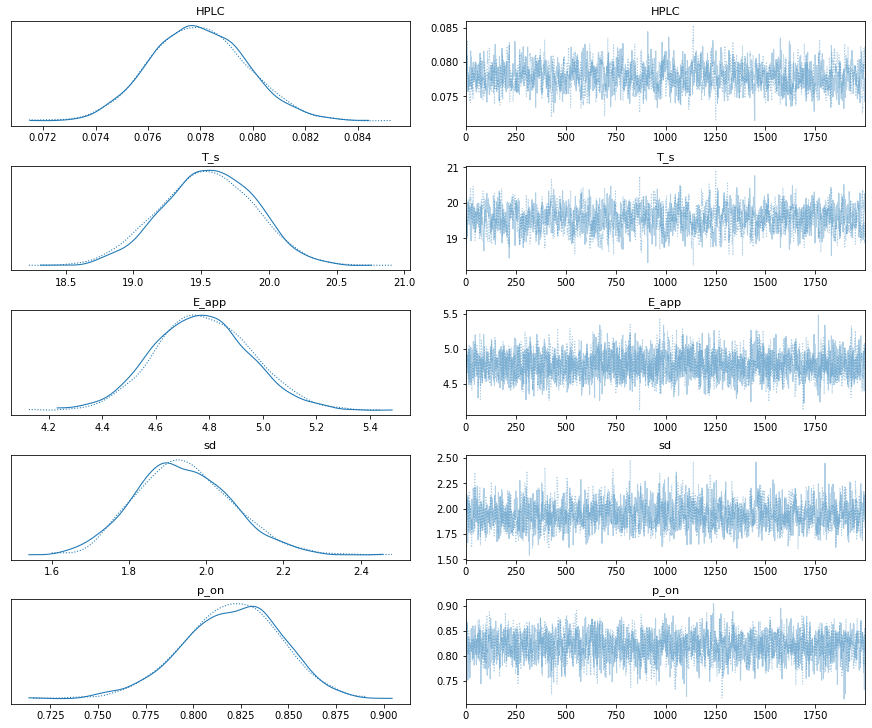

In [30]:
pm.traceplot(trace, var_names=['HPLC', 'T_s', 'E_app', 'sd', 'p_on']);

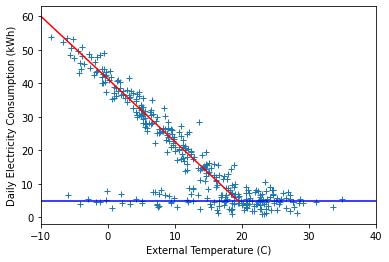

In [31]:
HPLC = np.mean(trace['HPLC'])
T_s = np.mean(trace['T_s'])
E_app = np.mean(trace['E_app'])

plt.plot(external_temp, observed, '+')
plt.plot([-10, 40], [E_app, E_app], 'b')

temp = np.linspace(-10, T_s, 1001)
plt.plot(temp, E_app + 24 * HPLC * (T_s - temp), 'r')

plt.ylabel("Daily Electricity Consumption (kWh)")
plt.xlabel("External Temperature (C)")
plt.xlim(-10, 40);

## Model for Houses 1 to 5

House 5 has yet more additional features that are not yet explicitly included in the model.
```

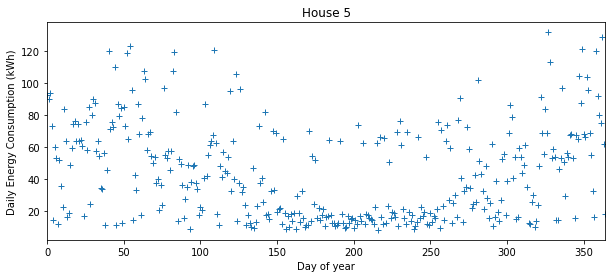

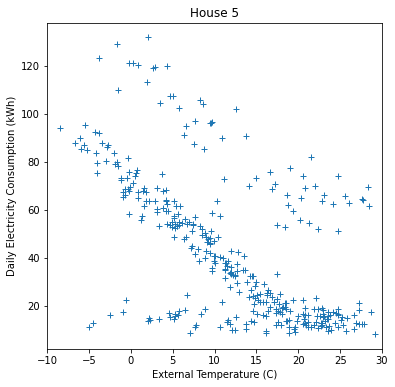

In [32]:
plotEnergyAgainstTime("House 5", energy_house_5)

plotEnergyAgainstTemperature("House 5", external_temp, energy_house_5)

This dataset shows an electric vehicle being charged on some days. We can further extend the model to include car charging by adding another Bernoulli random variable with a beta prior to indicate whether a car is charging. However, we have to be careful as the model can potentially learn to balance the heating being off with a car charging to reproduce the normal energy consumption behaviour.

We can avoid this outcome by explicitly avoiding the possibility that the heating is off and a car is charging. If this does actually happen the model can explain it as normal noise. We cando this by just adding additional parenthesis in the final energy expression.

We now model ```P_home``` and ```P_charge``` rather than ```P_on``` and ```P_car``` to make the intent of the model a little clearer.

However, the key change is modifying the energy expression from:

```
mu = E_app + P_on * E_heat + P_car * E_car
```

to the form shown below:

```
mu = E_app + P_home * (E_heat + P_charge * E_car)
```

In [33]:
N = 365

observed = energy_house_5

model = pm.Model() 

with model:
    
    # Prior distributions
    
    T_s = pm.Normal('T_s', mu=20.0, sd=2.0)

    E_app = pm.Gamma('E_app', mu=10.0, sd=10.0)
    
    E_car = pm.Gamma('E_car', mu=40.0, sd=10.0)
    
    sd = pm.Gamma('sd', mu=10.0, sd=5.0)
    
    HPLC = pm.Exponential('HPLC', lam=1.0/0.1)
    
    p_home = pm.Beta('p_home', 5, 2)
    
    P_home = pm.Bernoulli('P_home', p=p_home, shape=(N))
    
    p_charge = pm.Beta('p_charge', 2, 5)
    
    P_charge = pm.Bernoulli('P_charge', p=p_charge, shape=(N))

    # Observations
    
    temperature = pm.Normal('temperature', mu=10.0, sd=10.0, shape=(N))
    
    X_obs = pm.Normal('X_obs', mu=temperature, sd=2.0, observed=pm.Data('external_temp', external_temp))

    E_heat = pm.math.maximum(0.0, 24.0 * (T_s - temperature) * HPLC)
    
    mu = E_app + P_home * (E_heat + P_charge * E_car)
    
    Y_obs = pm.Gamma('Y_obs', mu=mu, sd=sd, observed=pm.Data('observed', observed))

In [34]:
with model:
    
    trace = pm.sample(draws=2000)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  This is separate from the ipykernel package so we can avoid doing imports until
Sequential sampling (2 chains in 1 job)
CompoundStep
>NUTS: [temperature, p_charge, p_home, HPLC, sd, E_car, E_app, T_s]
>BinaryGibbsMetropolis: [P_home, P_charge]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 824 seconds.
/usr/local/lib/python3.7/dist-packages/arviz/stats/diagnostics.py:561: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.05 for some parameters. This indicates slight problems during sampling.
The estimated number of effective samples is smaller than 200 for some parameters.


In [1]:
pm.traceplot(trace, var_names=['HPLC', 'T_s', 'E_app', 'sd', 'p_home', 'p_charge']);

NameError: ignored

In [ ]:
HPLC = np.mean(trace['HPLC'])
T_s = np.mean(trace['T_s'])
E_app = np.mean(trace['E_app'])

plt.plot(external_temp, observed, '+')
plt.plot([-10, 40], [E_app, E_app], 'b')

temp = np.linspace(-10, T_s, 1001)
plt.plot(temp, E_app + 24 * HPLC * (T_s - temp), 'r')

plt.ylabel("Daily Electricity Consumption (kWh)")
plt.xlabel("External Temperature (C)")
plt.xlim(-10, 40);